# Smoke and Air Quality Exposure on Tribal Lands
**Series:** Tribal Fire Science & Indigenous Data Sovereignty  
**Author:** Lilly Jones, PhD  
**Last Updated:** 2025  
**Data Sources:** EPA AQS PM2.5, Census TIGER Counties, Census ACS

## Overview
Fire risk analyses typically focus on what burns. This notebook focuses on what
people breathe. Wildfire smoke measured as fine particulate matter (PM2.5) 
is a direct, measurable public health impact that connects fire science to
community health outcomes.

This notebook quantifies smoke exposure on Tribal lands by:
- Counting annual smoke days (PM2.5 > 35 µg/m³) per Tribal land, 2010–2023
- Identifying coverage gaps in the EPA monitoring network
- Combining smoke exposure with demographic vulnerability (elderly, children)
- Producing a Smoke Health Vulnerability Index for each Tribal Nation

## Why This Matters for Tribal Decision Makers
90% of wildfires are human-caused. The smoke from fires burning near and on
Tribal lands affects community members who had no role in creating the
conditions that drive fire. This analysis quantifies that burden in terms
that connect to health policy, air quality funding, and federal trust
responsibility arguments.

## PM2.5 Smoke Thresholds
| PM2.5 (µg/m³) | AQI Category | Health Significance |
|---|---|---|
| > 12 | Moderate | Sensitive group concern |
| > 35 | Unhealthy for Sensitive Groups | **Smoke day threshold used here** |
| > 55 | Unhealthy | All groups affected |
| > 150 | Very Unhealthy / Hazardous | Heavy smoke event |

## Coverage Gap Note
EPA AQS monitors are sparse in rural and Tribal areas. Where no county-level
monitor data exists, this notebook documents the gap explicitly rather than
substituting an estimate. The monitoring gap itself is a policy finding.

For satellite-derived smoke coverage without monitor gaps, see:
NOAA Hazard Mapping System (HMS) Smoke Product:
https://www.ospo.noaa.gov/Products/land/hms.html

## Data Requirements
| Data | Source | Key Required |
|---|---|---|
| EPA AQS PM2.5 | EPA AQS API | `EPA_AQS_EMAIL` + `EPA_AQS_KEY` in `.env` |
| Tribal boundaries | Census TIGER | None |
| County boundaries | Census TIGER | None |
| Age demographics | Census ACS | `CENSUS_API_KEY` in `.env` |

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import os
import warnings
from datetime import datetime

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.validation import make_valid

from src.data import constants, loaders, validators
from src.data.constants import PRIMARY_TRIBES
from src.geo import utils as geo_utils
from src.indigenous.sovereignty import generate_citations, print_data_acknowledgment
from src.viz import charts, styles

styles.apply_mpl_style()
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

print(f"Repo root : {REPO_ROOT}")
print(f"Output dir: {constants.OUTPUTS_DIR}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repo root : C:\Users\gekek\Documents\tfs_refactor
Output dir: C:\Users\gekek\Documents\tfs_refactor\outputs
Analysis run: 2026-04-01 19:22


In [2]:
print_data_acknowledgment(source_keys=["census_aiannh", "epa_aqs"])

DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and fire histories. This project is guided by three
complementary data governance frameworks:

OCAP® — Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE  — Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR  — Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

We recognize that:

• Tribal Nations are sovereign governments with the right to control
  data about their own communities and terr

## Configuration

In [3]:
# Analysis parameters
TRIBES_OF_INTEREST  = PRIMARY_TRIBES
ANALYSIS_YEARS      = list(range(2010, 2024))  # 2010–2023

# PM2.5 thresholds
SMOKE_DAY_THRESHOLD_UGM3   = 35.0   # µg/m³ — Unhealthy for Sensitive Groups
HEAVY_SMOKE_THRESHOLD_UGM3 = 150.0  # µg/m³ — Very Unhealthy / Hazardous

# API credentials — stored in .env, never committed
EPA_AQS_EMAIL  = os.environ.get("EPA_AQS_EMAIL",  None)
EPA_AQS_KEY    = os.environ.get("EPA_AQS_KEY",    None)
CENSUS_API_KEY = os.environ.get("CENSUS_API_KEY", None)

EPA_AQS_AVAILABLE  = EPA_AQS_EMAIL is not None and EPA_AQS_KEY is not None
ACS_AVAILABLE      = CENSUS_API_KEY is not None

print("SMOKE EXPOSURE ANALYSIS CONFIGURATION")
print("=" * 55)
print(f"  Tribal Nations       : {len(TRIBES_OF_INTEREST)}")
print(f"  Analysis years       : {ANALYSIS_YEARS[0]}–{ANALYSIS_YEARS[-1]}")
print(f"  Smoke day threshold  : PM2.5 > {SMOKE_DAY_THRESHOLD_UGM3} µg/m³")
print(f"  Heavy smoke threshold: PM2.5 > {HEAVY_SMOKE_THRESHOLD_UGM3} µg/m³")
print(f"\nCredentials:")
print(f"  EPA AQS API  : {'SET' if EPA_AQS_AVAILABLE else 'NOT SET: register at https://aqs.epa.gov/data/api/signup'}")
print(f"  Census ACS   : {'SET' if ACS_AVAILABLE else 'NOT SET: demographic vulnerability will be skipped'}")

SMOKE EXPOSURE ANALYSIS CONFIGURATION
  Tribal Nations       : 10
  Analysis years       : 2010–2023
  Smoke day threshold  : PM2.5 > 35.0 µg/m³
  Heavy smoke threshold: PM2.5 > 150.0 µg/m³

Credentials:
  EPA AQS API  : NOT SET: register at https://aqs.epa.gov/data/api/signup
  Census ACS   : NOT SET: demographic vulnerability will be skipped


## Load Tribal and County Boundaries

In [4]:
# Tribal land boundaries 
all_tribal = loaders.load_census_aian()
all_tribal = validators.validate_geodataframe(
    all_tribal, "census_aiannh", required_columns=["geometry", "NAME"]
)
tribal_lands = all_tribal[all_tribal["NAME"].isin(TRIBES_OF_INTEREST)].copy()
tribal_lands = tribal_lands.dissolve(by="NAME", as_index=False).reset_index(drop=True)
tribal_lands["geometry"] = tribal_lands.geometry.apply(
    lambda g: make_valid(g) if g is not None else g
)
CONUS = geo_utils.bbox_geodataframe((-127, 24, -65, 50)).geometry.iloc[0]
tribal_lands = tribal_lands[
    tribal_lands.geometry.notnull() &
    tribal_lands.geometry.is_valid &
    tribal_lands.intersects(CONUS)
].copy().reset_index(drop=True)

print(f"Tribal Nations: {len(tribal_lands)}")

Tribal Nations: 10


In [5]:
# Census TIGER county boundaries 
counties = loaders.load_census_counties()
counties = validators.validate_geodataframe(
    counties, "census_counties",
    required_columns=["geometry", "GEOID", "STATEFP", "COUNTYFP"],
)
print(f"Counties loaded: {len(counties):,}")

Counties loaded: 3,235


In [6]:
# Spatial join: Tribal lands to overlapping counties
# Each Tribal land is matched to all counties it intersects.
# EPA AQS data will be queried for those county FIPS codes.

tribal_proj  = tribal_lands.to_crs("EPSG:5070")
counties_proj = counties.to_crs("EPSG:5070")

tribe_county = gpd.sjoin(
    tribal_proj[["NAME", "geometry"]],
    counties_proj[["GEOID", "STATEFP", "COUNTYFP", "NAME", "geometry"]]
    .rename(columns={"NAME": "county_name"}),
    how="left",
    predicate="intersects",
).drop(columns=["index_right"], errors="ignore").reset_index(drop=True)

print("Tribal Nation to County mapping:")
print("=" * 55)
for name in tribal_lands["NAME"]:
    counties_for_tribe = tribe_county[tribe_county["NAME"] == name]
    county_list = counties_for_tribe["county_name"].tolist()
    print(f"  {name}: {len(county_list)} counties ({', '.join(county_list[:3])}"
          f"{' ...' if len(county_list) > 3 else ''})")

Tribal Nation to County mapping:
  Cherokee: 27 counties (Pittsburg, McIntosh, Le Flore ...)
  Chickasaw: 23 counties (Cooke, Montague, Clay ...)
  Choctaw: 25 counties (Fannin, Lamar, Bryan ...)
  Colville: 7 counties (Grant, Lincoln, Stevens ...)
  Creek: 18 counties (Pontotoc, Pittsburg, Hughes ...)
  Fort Apache: 5 counties (Graham, Gila, Apache ...)
  Kiowa-Comanche-Apache-Fort Sill Apache: 19 counties (Clay, Wichita, Wilbarger ...)
  Osage: 8 counties (Tulsa, Pawnee, Noble ...)
  San Carlos: 6 counties (Graham, Greenlee, Pinal ...)
  Warm Springs: 8 counties (Jefferson, Linn, Wasco ...)


## Load EPA AQS PM2.5 Data
Queries EPA AQS daily PM2.5 for each county overlapping a Tribal land.
All results are cached: first run will take several minutes.

In [7]:
# EPA AQS PM2.5 download 
if not EPA_AQS_AVAILABLE:
    print(
        "EPA AQS credentials not set.\n"
        "Register at https://aqs.epa.gov/data/api/signup (free).\n"
        "Then add to .env:\n"
        "  EPA_AQS_EMAIL=your@email.com\n"
        "  EPA_AQS_KEY=your_key\n\n"
        "Analysis will continue but smoke day counts will not be available."
    )
    aqs_df = pd.DataFrame()
else:
    # Unique (state, county) pairs across all Tribal lands
    county_pairs = (
        tribe_county[["STATEFP", "COUNTYFP", "county_name"]]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )
    print(f"Querying EPA AQS for {len(county_pairs)} counties × {len(ANALYSIS_YEARS)} years...")
    print("Results cache to data/cache/ — subsequent runs are fast.")

    aqs_records = []
    no_monitor  = []

    for _, row in county_pairs.iterrows():
        state_fips  = str(row["STATEFP"]).zfill(2)
        county_fips = str(row["COUNTYFP"]).zfill(3)
        county_name = row["county_name"]
        has_data    = False

        for year in ANALYSIS_YEARS:
            try:
                daily = loaders.load_epa_aqs_pm25(
                    state_fips=state_fips,
                    county_fips=county_fips,
                    year=year,
                    email=EPA_AQS_EMAIL,
                    api_key=EPA_AQS_KEY,
                )
                if not daily.empty:
                    daily["county_name"] = county_name
                    aqs_records.append(daily)
                    has_data = True
            except Exception as e:
                pass  # Retry handled by tenacity in loader

        if not has_data:
            no_monitor.append(f"{county_name} ({state_fips}-{county_fips})")

    if aqs_records:
        aqs_df = pd.concat(aqs_records, ignore_index=True)
        aqs_df["date_local"] = pd.to_datetime(aqs_df["date_local"])
        print(f"\nEPA AQS data loaded: {len(aqs_df):,} county-day records")
        print(f"Date range: {aqs_df['date_local'].min().date()} — {aqs_df['date_local'].max().date()}")
    else:
        aqs_df = pd.DataFrame()
        print("No EPA AQS data returned.")

    if no_monitor:
        print(f"\n⚠ MONITORING COVERAGE GAP: No EPA AQS PM2.5 data found for:")
        for c in no_monitor:
            print(f"   {c}")
        print("  These areas may have unmonitored smoke exposure.")
        print("  See NOAA HMS Smoke Product for satellite-based alternative.")

EPA AQS credentials not set.
Register at https://aqs.epa.gov/data/api/signup (free).
Then add to .env:
  EPA_AQS_EMAIL=your@email.com
  EPA_AQS_KEY=your_key

Analysis will continue but smoke day counts will not be available.


## Compute Smoke Days Per Tribal Land

In [8]:
# Join AQS data to Tribal lands 
if not aqs_df.empty:
    # Join county PM2.5 to Tribal lands via tribe_county mapping
    county_tribe_map = (
        tribe_county[["NAME", "STATEFP", "COUNTYFP"]]
        .dropna()
        .drop_duplicates()
    )
    county_tribe_map["state_fips"]  = county_tribe_map["STATEFP"].astype(str).str.zfill(2)
    county_tribe_map["county_fips"] = county_tribe_map["COUNTYFP"].astype(str).str.zfill(3)

    aqs_tribal = aqs_df.merge(
        county_tribe_map[["NAME", "state_fips", "county_fips"]],
        on=["state_fips", "county_fips"],
        how="inner",
    )

    # For Tribes spanning multiple counties, take max PM2.5 across counties per day
    # (conservative: uses worst-case exposure within Tribal land)
    aqs_tribal_daily = (
        aqs_tribal.groupby(["NAME", "date_local", "year"])["pm25_ugm3"]
        .max()
        .reset_index()
    )

    # Smoke day flags
    aqs_tribal_daily["smoke_day"]  = aqs_tribal_daily["pm25_ugm3"] > SMOKE_DAY_THRESHOLD_UGM3
    aqs_tribal_daily["heavy_smoke"] = aqs_tribal_daily["pm25_ugm3"] > HEAVY_SMOKE_THRESHOLD_UGM3

    # Annual counts
    smoke_annual = (
        aqs_tribal_daily.groupby(["NAME", "year"])
        .agg(
            smoke_days=("smoke_day", "sum"),
            heavy_smoke_days=("heavy_smoke", "sum"),
            mean_pm25=("pm25_ugm3", "mean"),
            max_pm25=("pm25_ugm3", "max"),
            days_measured=("pm25_ugm3", "count"),
        )
        .reset_index()
    )

    print("ANNUAL SMOKE DAYS PER TRIBAL NATION")
    print("=" * 60)
    summary = (
        smoke_annual.groupby("NAME")[["smoke_days", "heavy_smoke_days", "mean_pm25"]]
        .mean().round(1)
        .sort_values("smoke_days", ascending=False)
    )
    print(summary.to_string())
else:
    smoke_annual = pd.DataFrame()
    print("No AQS data available: set EPA_AQS_EMAIL and EPA_AQS_KEY in .env")

No AQS data available: set EPA_AQS_EMAIL and EPA_AQS_KEY in .env


## Monitor Coverage Gap Analysis

In [9]:
# Identify Tribes with and without EPA monitor coverage 
# A coverage gap = Tribal land where no overlapping county has PM2.5 monitor data.
# This is itself a policy finding: monitoring inequity.

if not aqs_df.empty:
    tribes_with_data = set(smoke_annual["NAME"].unique())
    tribes_all       = set(tribal_lands["NAME"].unique())
    tribes_no_data   = tribes_all - tribes_with_data

    coverage_df = pd.DataFrame({
        "NAME":              list(tribes_all),
        "has_monitor_data":  [t in tribes_with_data for t in tribes_all],
    })
    # Add mean smoke days where available
    mean_smoke = smoke_annual.groupby("NAME")["smoke_days"].mean().round(1).reset_index()
    coverage_df = coverage_df.merge(mean_smoke, on="NAME", how="left")

    print(f"Tribes with EPA monitor coverage    : {len(tribes_with_data)}")
    print(f"Tribes with NO monitor coverage     : {len(tribes_no_data)}")
    if tribes_no_data:
        print(f"\n⚠ No EPA PM2.5 data for:")
        for t in sorted(tribes_no_data):
            print(f"   {t}")
        print(
            "\n  This is a monitoring equity gap. These Tribal Nations may\n"
            "  have significant smoke exposure that is not being measured.\n"
            "  Recommend NOAA HMS satellite smoke analysis for these areas,\n"
            "  and advocacy for expanded EPA monitoring on Tribal lands."
        )
else:
    coverage_df = pd.DataFrame()

## Demographic Vulnerability

In [10]:
# Census ACS age demographics
# Elderly (65+) and children (<18) are most vulnerable to PM2.5 health impacts.

if ACS_AVAILABLE:
    try:
        age_df = loaders.load_census_age_demographics(
            api_key=CENSUS_API_KEY, year=2022
        )
        print(f"ACS age demographics loaded: {len(age_df):,} counties")

        # Join to Tribal land → county mapping
        county_tribe_map = (
            tribe_county[["NAME", "STATEFP", "COUNTYFP"]]
            .dropna().drop_duplicates()
        )
        county_tribe_map["geoid"] = (
            county_tribe_map["STATEFP"].astype(str).str.zfill(2) +
            county_tribe_map["COUNTYFP"].astype(str).str.zfill(3)
        )
        demog_tribal = county_tribe_map.merge(age_df, on="geoid", how="left")

        # Average demographics across counties per Tribal land
        demog_by_tribe = (
            demog_tribal.groupby("NAME")
            .agg(
                total_pop=("total_pop", "sum"),
                pop_65plus=("pop_65plus", "sum"),
                pop_under18=("pop_under18", "sum"),
            )
            .reset_index()
        )
        demog_by_tribe["pct_65plus"]      = (demog_by_tribe["pop_65plus"]  / demog_by_tribe["total_pop"] * 100).round(1)
        demog_by_tribe["pct_under18"]     = (demog_by_tribe["pop_under18"] / demog_by_tribe["total_pop"] * 100).round(1)
        demog_by_tribe["vulnerability_pct"] = (demog_by_tribe["pct_65plus"] + demog_by_tribe["pct_under18"]).round(1)

        print("\nDemographic vulnerability by Tribal Nation:")
        print(
            demog_by_tribe[["NAME", "pct_65plus", "pct_under18", "vulnerability_pct"]]
            .sort_values("vulnerability_pct", ascending=False)
            .to_string(index=False)
        )
        ACS_LOADED = True

    except Exception as e:
        print(f"ACS loading failed: {e}")
        demog_by_tribe = pd.DataFrame()
        ACS_LOADED = False
else:
    demog_by_tribe = pd.DataFrame()
    ACS_LOADED = False
    print(
        "Census ACS API key not set: demographic vulnerability skipped.\n"
        "Get a free key at https://api.census.gov/data/key_signup.html"
    )

Census ACS API key not set: demographic vulnerability skipped.
Get a free key at https://api.census.gov/data/key_signup.html


## Smoke Health Vulnerability Index

In [11]:
# Combine smoke exposure and demographic vulnerability 
# Smoke Health Vulnerability Index (SHVI) = normalized smoke days × normalized
# demographic vulnerability. High SHVI = high exposure AND high vulnerable pop.

if not smoke_annual.empty and ACS_LOADED:
    # Mean annual smoke days per Tribe
    mean_smoke = (
        smoke_annual.groupby("NAME")
        .agg(
            mean_smoke_days=("smoke_days", "mean"),
            mean_heavy_smoke=("heavy_smoke_days", "mean"),
        )
        .round(1)
        .reset_index()
    )

    shvi = mean_smoke.merge(demog_by_tribe, on="NAME", how="outer")

    # Normalize both components 0–10
    def _norm(series):
        mn, mx = series.min(), series.max()
        if mx == mn:
            return pd.Series([5.0] * len(series), index=series.index)
        return (series - mn) / (mx - mn) * 10

    shvi["exposure_score"]      = _norm(shvi["mean_smoke_days"].fillna(0))
    shvi["vulnerability_score"] = _norm(shvi["vulnerability_pct"].fillna(shvi["vulnerability_pct"].median()))
    shvi["shvi"]                = ((shvi["exposure_score"] + shvi["vulnerability_score"]) / 2).round(2)
    shvi["shvi_category"]       = pd.cut(
        shvi["shvi"],
        bins=[-0.01, 3.33, 6.67, 10],
        labels=["Low", "Moderate", "High"],
    )

    print("SMOKE HEALTH VULNERABILITY INDEX (SHVI)")
    print("=" * 60)
    print("Combines smoke exposure (EPA AQS) with demographic vulnerability (Census ACS)")
    print()
    print(
        shvi[["NAME", "mean_smoke_days", "vulnerability_pct", "shvi", "shvi_category"]]
        .sort_values("shvi", ascending=False)
        .to_string(index=False)
    )
elif not smoke_annual.empty:
    # No demographics — SHVI based on smoke exposure only
    shvi = smoke_annual.groupby("NAME").agg(
        mean_smoke_days=("smoke_days", "mean"),
        mean_heavy_smoke=("heavy_smoke_days", "mean"),
    ).round(1).reset_index()
    shvi["shvi"] = _norm(shvi["mean_smoke_days"]).round(2) if len(shvi) > 1 else shvi["mean_smoke_days"]
    print("SHVI computed from smoke exposure only (no demographic data).")
    print(shvi.sort_values("shvi", ascending=False).to_string(index=False))
else:
    shvi = pd.DataFrame()
    print("SHVI requires EPA AQS data. Set EPA_AQS_EMAIL and EPA_AQS_KEY in .env.")

SHVI requires EPA AQS data. Set EPA_AQS_EMAIL and EPA_AQS_KEY in .env.


## Visualizations

In [12]:
# Time series: smoke days trend per Tribe 
if not smoke_annual.empty:
    tribes_monitored = smoke_annual["NAME"].unique()
    n = len(tribes_monitored)
    ncols = min(2, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 3.5), sharex=True)
    axes = np.array(axes).flatten()

    for i, name in enumerate(tribes_monitored):
        ax   = axes[i]
        data = smoke_annual[smoke_annual["NAME"] == name].sort_values("year")

        # Smoke days as bars
        ax.bar(data["year"], data["smoke_days"], color=styles.SMOKE_GRAY,
               alpha=0.7, label="Smoke days")
        # Heavy smoke days
        ax.bar(data["year"], data["heavy_smoke_days"], color=styles.EMBER_RED,
               alpha=0.8, label="Heavy smoke")
        # Trend line
        if len(data) > 2:
            z = np.polyfit(data["year"], data["smoke_days"], 1)
            ax.plot(data["year"], np.poly1d(z)(data["year"]),
                    color=styles.CHARCOAL, linewidth=1.5, linestyle="--", alpha=0.8)

        ax.set_title(name.split()[0], fontsize=9, fontweight="bold")
        ax.set_ylabel("Days/yr", fontsize=8)
        sns.despine(ax=ax)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.legend(
        handles=[
            mpatches.Patch(color=styles.SMOKE_GRAY, alpha=0.8, label=f"PM2.5 > {SMOKE_DAY_THRESHOLD_UGM3} µg/m³"),
            mpatches.Patch(color=styles.EMBER_RED, label=f"PM2.5 > {HEAVY_SMOKE_THRESHOLD_UGM3} µg/m³ (very unhealthy)"),
            plt.Line2D([0],[0], color=styles.CHARCOAL, linestyle="--", label="Trend"),
        ],
        loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 0),
    )
    plt.suptitle(
        "Annual Smoke Days per Tribal Land (EPA AQS PM2.5)",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    charts.save_figure(fig, "outputs/figures/smoke_days_time_series.png")
    plt.show()
else:
    print("No smoke data to plot.")

No smoke data to plot.


In [13]:
# SHVI scatter: exposure vs. vulnerability 
if not shvi.empty and "vulnerability_pct" in shvi.columns and "mean_smoke_days" in shvi.columns:
    fig, ax = plt.subplots(figsize=(10, 7))

    sc = ax.scatter(
        shvi["mean_smoke_days"].fillna(0),
        shvi["vulnerability_pct"].fillna(shvi["vulnerability_pct"].median()),
        s=200,
        c=shvi["shvi"],
        cmap="YlOrRd",
        edgecolors=styles.CHARCOAL,
        linewidth=0.8,
        alpha=0.85,
        vmin=0, vmax=10,
    )
    plt.colorbar(sc, ax=ax, label="Smoke Health Vulnerability Index (SHVI)")

    for _, row in shvi.iterrows():
        ax.annotate(
            row["NAME"].split()[0],
            (row.get("mean_smoke_days", 0), row.get("vulnerability_pct", 0)),
            xytext=(5, 4), textcoords="offset points", fontsize=8,
        )

    ax.axvline(
        shvi["mean_smoke_days"].median(), color="gray",
        linestyle="--", alpha=0.5, label="Median smoke days",
    )
    ax.axhline(
        shvi["vulnerability_pct"].median(), color="gray",
        linestyle=":", alpha=0.5, label="Median vulnerability %",
    )

    ax.set_xlabel("Mean annual smoke days (PM2.5 > 35 µg/m³)", fontsize=11)
    ax.set_ylabel("Vulnerable population % (elderly + children)", fontsize=11)
    ax.set_title(
        "Smoke Exposure vs. Demographic Vulnerability\n"
        "Upper right = highest compound health risk",
        fontsize=12, fontweight="bold",
    )
    ax.legend(fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    charts.save_figure(fig, "outputs/figures/smoke_health_vulnerability_scatter.png")
    plt.show()
else:
    print("SHVI scatter requires both AQS and ACS data.")

SHVI scatter requires both AQS and ACS data.


In [14]:
# SHVI bar chart 
if not shvi.empty and "shvi" in shvi.columns:
    fig, ax = plt.subplots(figsize=(11, 6))
    sorted_shvi = shvi.sort_values("shvi", ascending=True)

    SHVI_COLORS = {
        "High":     styles.EMBER_RED,
        "Moderate": styles.FIRE_ORANGE,
        "Low":      styles.SAGE_GREEN,
    }
    bar_colors = [
        SHVI_COLORS.get(str(c), styles.SMOKE_GRAY)
        for c in sorted_shvi.get("shvi_category", ["Low"] * len(sorted_shvi))
    ]

    ax.barh(sorted_shvi["NAME"], sorted_shvi["shvi"], color=bar_colors, alpha=0.85)
    ax.set_xlabel("Smoke Health Vulnerability Index (0–10)", fontsize=11)
    ax.set_title(
        "Smoke Health Vulnerability Index by Tribal Nation\n"
        "Combines PM2.5 exposure (EPA AQS) with vulnerable population % (Census ACS)",
        fontsize=11, fontweight="bold",
    )
    ax.legend(
        handles=[mpatches.Patch(color=v, label=k) for k, v in SHVI_COLORS.items()],
        fontsize=9,
    )
    ax.set_xlim(0, 10)
    sns.despine(ax=ax)
    plt.tight_layout()
    charts.save_figure(fig, "outputs/figures/smoke_health_vulnerability_index.png")
    plt.show()
else:
    print("SHVI chart requires smoke data.")

SHVI chart requires smoke data.


Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\smoke_exposure_coverage_map.png


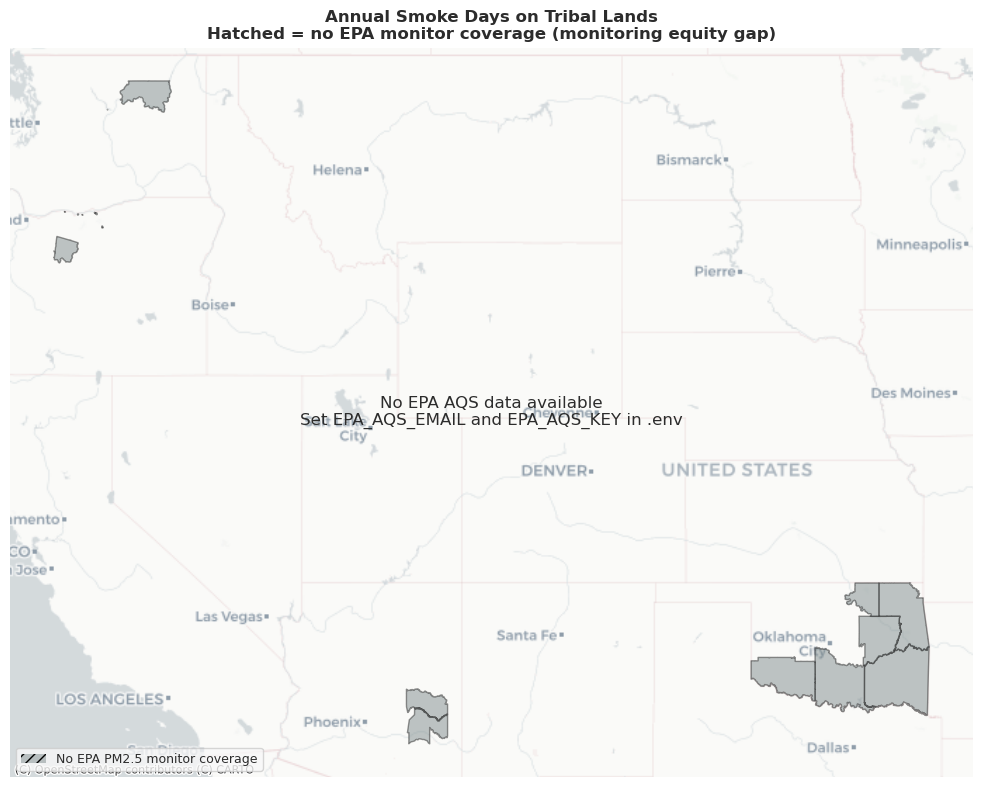

In [15]:
# Monitor coverage gap map 
fig, ax = plt.subplots(figsize=(13, 8))

if not shvi.empty and "mean_smoke_days" in shvi.columns:
    # Color Tribal lands by mean smoke days where data exists, gray where not
    tribal_plot = tribal_lands.merge(shvi[["NAME", "mean_smoke_days"]], on="NAME", how="left")

    # Tribes with data
    has_data = tribal_plot[tribal_plot["mean_smoke_days"].notna()]
    no_data  = tribal_plot[tribal_plot["mean_smoke_days"].isna()]

    if not has_data.empty:
        has_data.to_crs(3857).plot(
            column="mean_smoke_days", cmap="YlOrBr",
            ax=ax, edgecolor=styles.CHARCOAL, linewidth=1.5,
            legend=True,
            legend_kwds={"label": "Mean annual smoke days", "shrink": 0.6},
        )
    if not no_data.empty:
        no_data.to_crs(3857).plot(
            ax=ax, color=styles.SMOKE_GRAY, edgecolor=styles.CHARCOAL,
            linewidth=1.5, hatch="///", alpha=0.5,
        )

    # Label Tribal lands
    for _, row in tribal_plot.iterrows():
        cx = row.geometry.centroid.x
        cy = row.geometry.centroid.y
        proj_cx = gpd.GeoSeries([row.geometry.centroid], crs=constants.CRS_GEOGRAPHIC).to_crs(3857).iloc[0].x
        proj_cy = gpd.GeoSeries([row.geometry.centroid], crs=constants.CRS_GEOGRAPHIC).to_crs(3857).iloc[0].y
        label = row["NAME"].split()[0]
        if pd.notna(row.get("mean_smoke_days")):
            label += f"\n{row['mean_smoke_days']:.0f} d/yr"
        else:
            label += "\n⚠ No monitor"
        ax.annotate(label, (proj_cx, proj_cy), ha="center", fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
else:
    tribal_lands.to_crs(3857).plot(
        ax=ax, color=styles.SMOKE_GRAY, edgecolor=styles.CHARCOAL, alpha=0.5
    )
    ax.text(0.5, 0.5, "No EPA AQS data available\nSet EPA_AQS_EMAIL and EPA_AQS_KEY in .env",
            transform=ax.transAxes, ha="center", va="center", fontsize=12)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception:
    pass

ax.set_axis_off()
ax.set_title(
    "Annual Smoke Days on Tribal Lands\n"
    "Hatched = no EPA monitor coverage (monitoring equity gap)",
    fontsize=12, fontweight="bold",
)
ax.legend(
    handles=[
        mpatches.Patch(facecolor=styles.SMOKE_GRAY, hatch="///", alpha=0.5,
                       label="No EPA PM2.5 monitor coverage"),
    ],
    loc="lower left", fontsize=9,
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/smoke_exposure_coverage_map.png")
plt.show()

## Exports

In [16]:
if not smoke_annual.empty:
    smoke_annual.to_csv(
        constants.OUTPUTS_DIR / "smoke_days_annual.csv", index=False
    )
    print("Exported to outputs/smoke_days_annual.csv")

if not shvi.empty:
    shvi.assign(
        shvi_category=lambda df: df["shvi_category"].astype(str)
        if "shvi_category" in df.columns else "N/A"
    ).to_csv(
        constants.OUTPUTS_DIR / "smoke_health_vulnerability_index.csv", index=False
    )
    print("Exported to outputs/smoke_health_vulnerability_index.csv")

if not coverage_df.empty:
    coverage_df.to_csv(
        constants.OUTPUTS_DIR / "smoke_monitor_coverage_gap.csv", index=False
    )
    print("Exported to outputs/smoke_monitor_coverage_gap.csv")

## Summary and Findings

*(Fill in after running with real data.)*

**What the data shows:**
- Which Tribal Nations have the most annual smoke days, and is the trend
  increasing? A positive trend line on the time series is a direct evidence
  statement for policy conversations.
- How many Tribal Nations fall in the monitoring coverage gap? That number
  alone is a policy argument for expanded EPA monitoring investment.
- Which Tribal Nations have the highest SHVI combining high smoke exposure
  with high proportions of elderly residents and children?

**Connection to the rest of the series:**
- Cross-reference with `fast_fire_days_analysis.ipynb`: do Tribes with the
  most fast-fire days also have the most smoke days? If yes, the compounding
  exposure story (fire risk AND smoke burden) strengthens the case for
  proportional federal investment.
- Cross-reference with `climate_projections_tribal_fire_weather.ipynb` —
  if fire weather days are projected to increase, smoke burden will follow.

**Key limitations:**
- EPA AQS monitors are county-level and sparse in rural areas. Tribal lands
  in unmonitored counties may have significant smoke exposure that this
  analysis cannot quantify. The NOAA HMS satellite product has full spatial
  coverage but requires additional data engineering.
- PM2.5 readings include non-wildfire sources (vehicles, industry). The analysis
  does not isolate fire-attributed PM2.5. For fire-specific attribution, see
  the EPA Smoke Impacts Tool or Jaffe et al. (2020) fire smoke attribution methods.
- Demographic data is county-level from ACS and may not reflect Tribal
  enrollment demographics, which differ from county population.

**For Tribal decision makers:**
The SHVI and monitoring gap findings directly support:
- BIA and EPA budget requests for Tribal air quality monitoring
- Section 309 air quality program funding under the Clean Air Act
- Health impact assessments for Tribal climate adaptation plans
- Connections between fire management investment and public health outcomes

---
## References

In [17]:
print(generate_citations(["census_aiannh", "epa_aqs", "census_acs"]))

References / Data Sources
----------------------------------------
- Census TIGER AIANNH. US Census Bureau. https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
- EPA Air Quality System (AQS) Daily PM2.5. US Environmental Protection Agency. https://aqs.epa.gov/data/api/
- Census American Community Survey (ACS) 5-Year Estimates. US Census Bureau. https://api.census.gov/data/
